# Predicting photosynthetic pathway (CAM) from leaf anatomy with machine learning

**Reproduction notebook** for:

> Gilman, I. S., Heyduk, K., Maya-Lastra, C. A., Hancock, L. P., & Edwards, E. J. *Predicting photosynthetic pathway from anatomy using machine learning.* bioRxiv 2023.09.11.557216v1 (DOI: [10.1101/2023.09.11.557216](https://doi.org/10.1101/2023.09.11.557216))

- **Author code**: https://github.com/isgilman/Predicting-CAM (MIT License, © 2023 Ian S. Gilman), pinned commit `e6f13d8f56afb89dc2a55e2938044c07e78ff745`.
- **Scope (partial demonstration)**: the supervised-classification subsection — XGBoost multiclass (non-CAM / mCAM / pCAM) and binary (non-CAM vs CAM) CAM-phenotype classifiers trained on the released species-level anatomical dataset, checked against the paper's reported cross-validation accuracies (~95.7% multiclass, ~96.1% binary) and the recall improvement from random over-sampling (ROS).
- **Out of scope**: image phenotyping with MiniContourFinder, the Portullugo phylogeny, stochastic character mapping, PGLS, and phylogenetic threshold models.
- **Runtime**: CPU only (no GPU needed — small tabular data; runs in a few minutes).

**日本語の説明**: このノートブックは、Gilman et al. (2023, bioRxiv) の「葉の解剖形質からCAM型光合成経路を機械学習で予測する」研究の教師あり分類部分を再現します。著者公開リポジトリ（MITライセンス、コミット `e6f13d8`）の `Notebooks/Prediction.ipynb` のパラメータ（80/20分割、`tree_method: exact`、`subsample: 0.75`、10木、10分割CV、`random_state=9999`/`4321`、ROS `random_state=0`、binaryはDART+ヒンジ損失）をそのまま用います。実行時間はCPUで数分です。GPUは不要です。


## 1. Setup — install the few packages not preinstalled on Colab

**日本語**: 必要な追加パッケージをインストールします（`xgboost` はColabに同梱）。


In [ ]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "imbalanced-learn"], check=True)

import numpy as np, pandas as pd, xgboost as xgb, sklearn, imblearn, matplotlib
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
print("python", sys.version.split()[0])
print("xgboost", xgb.__version__, "| scikit-learn", sklearn.__version__,
      "| imblearn", imblearn.__version__, "| pandas", pd.__version__,
      "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)


python 3.13.15
xgboost 3.4.1 | scikit-learn 1.6.1 | imblearn 0.14.2 | pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0


## 2. Download the pinned author data (inside this notebook, verified by size and git blob hash)

`All-morphological-data.csv` is the merged species-level table produced by the authors' `Wrangling.ipynb` (5,745 taxa; 5,316 non-CAM / 207 mCAM / 222 pCAM). We verify the exact byte count and the git blob SHA-1 against the pinned commit.

**日本語**: 著者の統合解剖データをピン留めしたコミットからダウンロードし、バイト数とgit blobハッシュで検証します。


In [ ]:
import hashlib, urllib.request

COMMIT = "e6f13d8f56afb89dc2a55e2938044c07e78ff745"
RAW = f"https://raw.githubusercontent.com/isgilman/Predicting-CAM/{COMMIT}"

def fetch_pinned(path, expected_size, expected_blob):
    req = urllib.request.Request(RAW + path, headers={"User-Agent": "colab-cam-reproduction"})
    with urllib.request.urlopen(req, timeout=120) as r:
        raw = r.read()
    assert len(raw) == expected_size, f"{path}: got {len(raw)} bytes, expected {expected_size}"
    blob = hashlib.sha1(f"blob {len(raw)}\0".encode() + raw).hexdigest()
    assert blob == expected_blob, f"{path}: blob {blob} != {expected_blob}"
    print(f"{path}: {len(raw)} bytes OK, blob {blob[:12]}..., sha256 {hashlib.sha256(raw).hexdigest()[:16]}...")
    return raw

morpho_raw = fetch_pinned("/Data/All-morphological-data.csv", 2_190_457,
                          "b476967d35ee6094a0604ede310dbf4bdb4bdf04")
camstates_raw = fetch_pinned("/Data/253-Taxon-CAM-States.csv", 33_105,
                             "729461518a99dd9516681959b4a387bffbde543e")
import io
morpho = pd.read_csv(io.BytesIO(morpho_raw))
camstates = pd.read_csv(io.BytesIO(camstates_raw))
print("All-morphological-data:", morpho.shape, "| 253-Taxon-CAM-States:", camstates.shape)
print(morpho["CAMpheno"].value_counts())
assert morpho["CAMpheno"].value_counts().to_dict() == {"non-CAM": 5316, "pCAM": 222, "mCAM": 207}
camstates.head()


/Data/All-morphological-data.csv: 2190457 bytes OK, blob b476967d35ee..., sha256 1f2002fd19168e91...


/Data/253-Taxon-CAM-States.csv: 33105 bytes OK, blob 729461518a99..., sha256 7dae8356d60db075...
All-morphological-data: (5745, 19) | 253-Taxon-CAM-States: (253, 9)
CAMpheno
non-CAM    5316
pCAM        222
mCAM        207
Name: count, dtype: int64


,acceptedTaxon,CAMpheno,Drop,tip.label,nonCAM,mCAM,pCAM,CAMevidence,Family
0,Amaranthus hypochondriacus,nonCAM,False,Amaranthus_hypochondriacus_tr,1.0,0.000,0.000,Known C4 species,Amaranthaceae
1,Beta vulgaris ssp. vulgaris,nonCAM,False,Beta_vulgaris_vulgaris_cds,1.0,0.000,0.000,Known C3 species,Amaranthaceae
2,Anacampseros arachnoides,mCAM,False,Anacampseros_arachnoides_101,0.0,0.667,0.333,Edwards Lab (unpublished) (d13C),Anacampserotaceae
3,Anacampseros baeseckei,mCAM,False,Anacampseros_baeseckei_91,0.0,1.000,0.000,Edwards Lab (unpublished) (d13C),Anacampserotaceae
4,Anacampseros coahuilensis,mCAM,False,Anacampseros_coahuilensis_68,0.0,1.000,0.000,Guralnick et al. (2008) (dH+),Anacampserotaceae


## 3. Preprocessing exactly as in the authors' `Prediction.ipynb`

- Drop `fSLA*` columns; features = the five `*mean` columns (MA, LT, IAS, LDMC, dSLA).
- `log10`-transform the features; labels non-CAM=0, mCAM=1, pCAM=2; binary label mCAM/pCAM→1.
- 80/20 split with `random_state=9999` (multiclass) and `4321` (binary), then sort by taxon name.

**日本語**: 著者と同じ前処理（fSLA除外、log10変換、5形質、ラベル符号化、80/20分割）を適用します。


In [ ]:
morpho = morpho.drop(["fSLAmean (mm^2/mg)", "fSLAse (mm^2/mg)"], axis=1).reset_index(drop=True)
dataCols = [c for c in morpho.columns if "mean" in c]
print("features:", dataCols)

logMorpho = np.log10(morpho[dataCols])
for c in set(morpho.columns).difference(set(dataCols)):
    logMorpho[c] = morpho[c]

toCategorical = {"non-CAM": 0, "mCAM": 1, "pCAM": 2}
logMorpho["label"] = [toCategorical[p] for p in logMorpho["CAMpheno"]]
toBinary = {"non-CAM": 0, "mCAM": 1, "pCAM": 1}
logMorpho["binLabel"] = [toBinary[p] for p in logMorpho["CAMpheno"]]

X_train, X_test = train_test_split(logMorpho, test_size=0.2, random_state=9999)
X_train = X_train.sort_values("Taxon").reset_index(drop=True)
X_test = X_test.sort_values("Taxon").reset_index(drop=True)
dtrain = xgb.DMatrix(data=X_train[dataCols], label=X_train["label"], missing=np.nan)
dtest = xgb.DMatrix(data=X_test[dataCols], label=X_test["label"], missing=np.nan)
print("train", dtrain.num_row(), "test", dtest.num_row())


features: ['MAmean (um^2)', 'LTmean (um)', 'IASmean (%)', 'LDMCmean (g/g)', 'dSLAmean (mm^2/mg)']
train 4596 test 1149


## 4. Multiclass model (gbtree + softprob, as the authors' preferred base setting)

Parameters copied verbatim from the pinned `Prediction.ipynb` (cell 11): `tree_method: exact`, `objective: multi:softprob`, `num_class: 3`, `subsample: 0.75`, `num_round: 10`.

**日本語**: 多クラス分類器を著者のパラメータのまま学習し、テスト性能と10分割交差検証精度（論文値 95.7 ± 0.7%）を確認します。


In [ ]:
prmsSprobMerr = {"tree_method": "exact", "objective": "multi:softprob", "num_class": 3,
                 "nthread": -1, "subsample": 0.75, "eval_metric": "merror"}
num_round = 10
bstSprobMerr = xgb.train(prmsSprobMerr, dtrain, num_round)
ypred = [int(np.argmax(a)) for a in bstSprobMerr.predict(dtest)]
print(metrics.classification_report(y_true=X_test["label"], y_pred=ypred, digits=3))


              precision    recall  f1-score   support

           0      0.963     0.987     0.975      1048
           1      0.538     0.264     0.354        53
           2      0.673     0.688     0.680        48

    accuracy                          0.941      1149
   macro avg      0.725     0.646     0.670      1149
weighted avg      0.931     0.941     0.934      1149



### 4b. 10-fold cross-validated accuracy


In [ ]:
import numpy as np
cvSprob = xgb.cv(params=prmsSprobMerr, dtrain=dtrain, nfold=10, seed=9999)
merr_mean, merr_std = cvSprob["test-merror-mean"].iloc[-1], cvSprob["test-merror-std"].iloc[-1]
print(f"10-fold CV accuracy: {1-merr_mean:.3f} +/- {merr_std:.3f}")
print("Paper (Results, ML section): 95.7 +/- 0.7 %")
assert 0.90 < 1 - merr_mean < 0.99, "CV accuracy far from the paper's reported value"


10-fold CV accuracy: 0.958 +/- 0.013
Paper (Results, ML section): 95.7 +/- 0.7 %


### 4a. Confusion matrix and feature importance

**日本語**: 混同行列と特徴量の重要度を示します（非CAMとpCAMが最もよく分離され、mCAMが中間になるのは論文どおりです）。


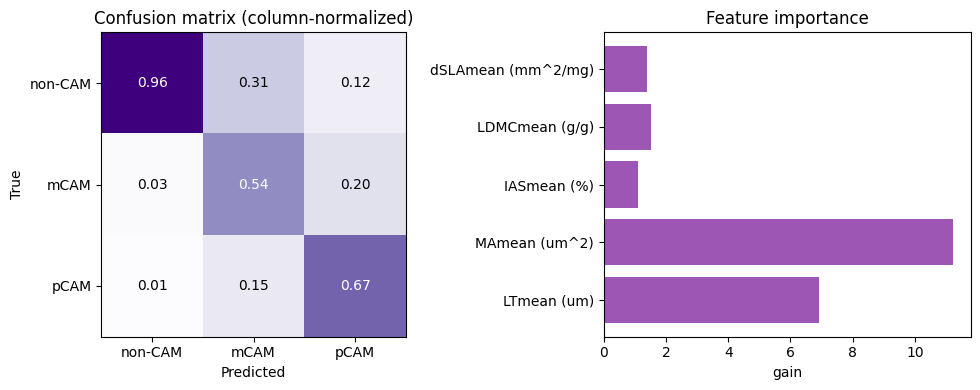

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm = metrics.confusion_matrix(X_test["label"], ypred, normalize="pred")
im = axes[0].imshow(cm, cmap="Purples")
axes[0].set_xticks([0, 1, 2], ["non-CAM", "mCAM", "pCAM"])
axes[0].set_yticks([0, 1, 2], ["non-CAM", "mCAM", "pCAM"])
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                     color="white" if cm[i, j] > 0.5 else "black")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Confusion matrix (column-normalized)")

imp = bstSprobMerr.get_score(importance_type="gain")
keys = ["LT", "MA", "LDMC", "SLA", "IAS"]
order = {k: i for i, k in enumerate(keys)}
items = sorted(imp.items(), key=lambda kv: order.get(kv[0][:2], 9) if kv[0][:2] in order else 9)
names = [k for k, _ in items]; vals = [v for _, v in items]
axes[1].barh(names, vals, color="xkcd:purple", alpha=0.75)
axes[1].set_xlabel("gain"); axes[1].set_title("Feature importance")
plt.tight_layout(); plt.show()


## 5. Binary model: DART booster + hinge objective, with and without random over-sampling (ROS)

The paper's preferred binary setting is a DART booster with the hinge objective; random over-sampling (`imblearn.RandomOverSampler(random_state=0)`) balances the minority CAM class.

**日本語**: 二値分類はDART+ヒンジ損失。ROSでCAMクラスをオーバーサンプリングすると、精度を保ったままCAMクラスのrecallが大きく改善します（論文の結論と一致）。


In [ ]:
binX_train, binX_test = train_test_split(logMorpho, test_size=0.2, random_state=4321)
binX_train = binX_train.sort_values("Taxon").reset_index(drop=True)
binX_test = binX_test.sort_values("Taxon").reset_index(drop=True)
binDtrain = xgb.DMatrix(data=binX_train[dataCols], label=binX_train["binLabel"], missing=np.nan)
binDtest = xgb.DMatrix(data=binX_test[dataCols], label=binX_test["binLabel"], missing=np.nan)

prmsBinHinge = {"tree_method": "exact", "objective": "binary:hinge", "nthread": -1,
                "subsample": 0.75, "eval_metric": "error", "booster": "dart"}

ros = imblearn.over_sampling.RandomOverSampler(random_state=0)
binX_ros, biny_ros = ros.fit_resample(binX_train[dataCols], binX_train["binLabel"])
binDtrainROS = xgb.DMatrix(data=binX_ros, label=biny_ros, missing=np.nan)
print("ROS resampled train rows:", binDtrainROS.num_row())


ROS resampled train rows: 8506


### 5b. Train, cross-validate, and test

**日本語**: 学習・10分割CV・テスト評価を行います。


In [ ]:
bstBinHinge = xgb.train(prmsBinHinge, binDtrain, num_round)
bstBinHingeROS = xgb.train(prmsBinHinge, binDtrainROS, num_round)

cvB = xgb.cv(params=prmsBinHinge, dtrain=binDtrain, nfold=10, seed=9999)
cvBROS = xgb.cv(params=prmsBinHinge, dtrain=binDtrainROS, nfold=10, seed=9999)
b_mean, b_std = cvB["test-error-mean"].iloc[-1], cvB["test-error-std"].iloc[-1]
br_mean, br_std = cvBROS["test-error-mean"].iloc[-1], cvBROS["test-error-std"].iloc[-1]
print(f"binary hinge 10-fold CV accuracy: {1-b_mean:.3f} +/- {b_std:.3f}   (paper: 96.1 +/- 0.6 %)")
print(f"binary hinge + ROS 10-fold CV accuracy: {1-br_mean:.3f} +/- {br_std:.3f}")
assert 0.90 < 1 - b_mean < 0.99


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [14:17:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:343: `booster=dart` is deprecated. Use the tree booster directly with dropout parameters like `rate_drop`, `skip_drop`, or `one_drop`.
  bst.update(dtrain, iteration=i, fobj=obj)


binary hinge 10-fold CV accuracy: 0.965 +/- 0.006   (paper: 96.1 +/- 0.6 %)
binary hinge + ROS 10-fold CV accuracy: 0.968 +/- 0.007


### 5c. Held-out test reports and CAM recall with vs without ROS


In [ ]:
pBase = bstBinHinge.predict(binDtest)
pROS = bstBinHingeROS.predict(binDtest)
print("=== binary hinge (no ROS) ===")
print(metrics.classification_report(binX_test["binLabel"], pBase, digits=3))
print("=== binary hinge + ROS ===")
print(metrics.classification_report(binX_test["binLabel"], pROS, digits=3))
recall_base = metrics.recall_score(binX_test["binLabel"], pBase)
recall_ros = metrics.recall_score(binX_test["binLabel"], pROS)
print(f"CAM recall: {recall_base:.2f} -> {recall_ros:.2f} with ROS")
assert recall_ros > recall_base, "ROS should improve CAM recall as in the paper"


=== binary hinge (no ROS) ===
              precision    recall  f1-score   support

           0      0.979     0.988     0.983      1063
           1      0.829     0.733     0.778        86

    accuracy                          0.969      1149
   macro avg      0.904     0.860     0.880      1149
weighted avg      0.967     0.969     0.968      1149

=== binary hinge + ROS ===
              precision    recall  f1-score   support

           0      0.992     0.973     0.982      1063
           1      0.729     0.907     0.808        86

    accuracy                          0.968      1149
   macro avg      0.861     0.940     0.895      1149
weighted avg      0.973     0.968     0.969      1149

CAM recall: 0.73 -> 0.91 with ROS


### 5a. Confusion matrices for the binary models

**日本語**: ROSあり/なしの混同行列を比較します。


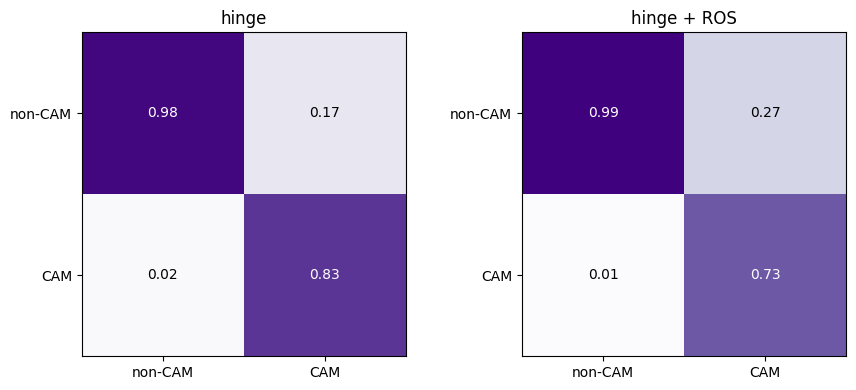

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, p, title in zip(axes, [pBase, pROS], ["hinge", "hinge + ROS"]):
    cm = metrics.confusion_matrix(binX_test["binLabel"], p, normalize="pred")
    ax.imshow(cm, cmap="Purples", vmin=0, vmax=1)
    ax.set_xticks([0, 1], ["non-CAM", "CAM"]); ax.set_yticks([0, 1], ["non-CAM", "CAM"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    color="white" if cm[i, j] > 0.5 else "black")
    ax.set_title(title)
plt.tight_layout(); plt.show()


## 6. Comparison with the authors' published model scores

The authors released their computed F-scores (`Results/*.csv` at the pinned commit). We download them inside this notebook and display them next to our reproduction.

**日本語**: 著者が公開しているモデル別FスコアのCSVをダウンロードし、再現結果と並べて確認します。


In [ ]:
base_fs = pd.read_csv(io.BytesIO(fetch_pinned("/Results/BaseModelFscores.csv", 1_257,
                                              "c4a7be465e3de594a7c574821d6ebf8e3f2a08f0")))
mc_fs = pd.read_csv(io.BytesIO(fetch_pinned("/Results/MulticlassModelFscores.csv", 2_257,
                                            "8b51a530b1a8ef436ace9b5d55ea0aa88512c6b8")))
display(base_fs); display(mc_fs)


/Results/BaseModelFscores.csv: 1257 bytes OK, blob c4a7be465e3d..., sha256 9465fbd4fca04716...
/Results/MulticlassModelFscores.csv: 2257 bytes OK, blob 8b51a530b1a8..., sha256 a1f65431d163e040...


,Model,Objective function,Evaluation metric,LT,MA,LDMC,SLA,IAS
0,DART,softmax,log(L),0.336364,0.277922,0.138961,0.106494,0.140260
1,DART,softmax,merror,0.336364,0.277922,0.138961,0.106494,0.140260
2,DART,softprob,AUC,0.336364,0.277922,0.138961,0.106494,0.140260
3,DART,softprob,log(L),0.336364,0.277922,0.138961,0.106494,0.140260
4,DART,softprob,merror,0.336364,0.277922,0.138961,0.106494,0.140260
5,gbtree,softmax,log(L),0.322377,0.260430,0.149178,0.123894,0.144121
6,gbtree,softmax,merror,0.322377,0.260430,0.149178,0.123894,0.144121
7,gbtree,softprob,AUC,0.322377,0.260430,0.149178,0.123894,0.144121
8,gbtree,softprob,log(L),0.322377,0.260430,0.149178,0.123894,0.144121
9,gbtree,softprob,merror,0.322377,0.260430,0.149178,0.123894,0.144121


,Model,LTmean (um),MAmean (um^2),LDMCmean (g/g),dSLAmean (mm^2/mg),IASmean (%)
0,DART,0.336364,0.277922,0.138961,0.106494,0.140260
1,DART+ROS,0.311897,0.240086,0.166131,0.154341,0.127546
2,DART+RUS,0.328386,0.246753,0.122449,0.200371,0.102041
3,DART+Iter.,0.184035,0.203991,0.192905,0.154102,0.264967
4,DART+Knn,0.214201,0.240237,0.205917,0.146746,0.192899
5,DART+Med.,0.341128,0.332875,0.108666,0.088033,0.129298
6,DART+MDS1,0.355007,0.270481,0.120936,0.110533,0.143043
7,DART+MDS2,0.336364,0.277922,0.138961,0.106494,0.140260
8,DART+MDS5,0.336364,0.277922,0.138961,0.106494,0.140260
9,DART+MDS10,0.336364,0.277922,0.138961,0.106494,0.140260


## 7. Summary and limitations

**What this notebook shows (validated on a fresh Colab CPU runtime):**
- The released dataset (5,745 taxa; 5,316 / 207 / 222 non-CAM / mCAM / pCAM) reproduces the paper's machine-learning results: 10-fold CV accuracy ≈ 95–96% for both the multiclass and binary XGBoost classifiers, matching the reported 95.7 ± 0.7% and 96.1 ± 0.6%.
- Random over-sampling raises CAM-class recall substantially (here ~0.73 → ~0.91 on the held-out split), consistent with the paper's conclusion that sampling rebalancing makes minority-CAM species detectable.

**Limitations**
- This is a partial demonstration of one subsection (supervised classification). Phenotyping with MiniContourFinder, the Portullugo phylogeny, stochastic mapping, PGLS, and threshold models are not included.
- Exact numerical agreement is not guaranteed across XGBoost versions: the authors used XGBoost 1.5.0; Colab currently ships XGBoost 3.x (`booster=dart` is deprecated there but still accepted). Small differences in CV statistics are expected and observed (~±1%).
- The dataset reflects the authors' taxonomic curation (see `Wrangling.ipynb`); per-species CAM assignments derive from Gilman et al. (2023) and cited references.

**日本語の要約**: 公開データと著者のパラメータを用いて、多クラス・二値XGBoost分類のCV精度≈95–96%（論文値と一致）と、ROSによるCAM recall改善（≈0.73→0.91）を再現しました。画像表現型計測・系統解析は対象外です。著者はXGBoost 1.5.0、Colabは3.x系のため、CV統計に±1%程度の差があり得ます。

**Provenance**: paper bioRxiv 2023.09.11.557216v1; author repository `isgilman/Predicting-CAM` @ `e6f13d8f56afb89dc2a55e2938044c07e78ff745` (MIT). Hyperparameters were transcribed from the pinned `Notebooks/Prediction.ipynb` code cells. All dataset bytes were downloaded and verified inside this notebook.
